## <center><b> Statistical analysis

### <center> Normality testing

In [1]:
import numpy as np
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import os

In [2]:
load_dotenv('vars.env')
DATA_PATH = os.getenv("DATA_PATH")


In [3]:
# Collect paths from patient records
patients = []
vital_base = os.path.join(DATA_PATH, 'Vital data')
hs_base    = os.path.join(DATA_PATH, 'HemoSphere data')

for folder in sorted(os.listdir(vital_base)):
    vital_pad = os.path.join(vital_base, folder, 'vital.csv')
    hs_pad    = os.path.join(hs_base,    folder, 'hemosphere.csv')

    if os.path.exists(vital_pad) and os.path.exists(hs_pad):
        patients.append((vital_pad, hs_pad))

for v, h in patients:
    print(f"Vital: {v}, Hemosphere: {h}")

patient_ids = []
for vital_path, hs_path in patients:
    naam = os.path.basename(os.path.dirname(vital_path))
    patient_id = int(naam.replace('MARTINI_', ''))
    patient_ids.append(patient_id)

print(f'Patiënt IDs: {patient_ids}')
print(f"N patients: {len(patient_ids)}")
df_demo = pd.read_csv(os.path.join(DATA_PATH, 'df_baseline.csv'), sep=';')
df_final = df_demo[df_demo['Participant Id'].isin(patient_ids)].copy()

Vital: P:\Vital data\MARTINI_110002\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110002\hemosphere.csv
Vital: P:\Vital data\MARTINI_110006\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110006\hemosphere.csv
Vital: P:\Vital data\MARTINI_110007\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110007\hemosphere.csv
Vital: P:\Vital data\MARTINI_110008\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110008\hemosphere.csv
Vital: P:\Vital data\MARTINI_110009\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110009\hemosphere.csv
Vital: P:\Vital data\MARTINI_110011\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110011\hemosphere.csv
Vital: P:\Vital data\MARTINI_110015\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110015\hemosphere.csv
Vital: P:\Vital data\MARTINI_110016\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110016\hemosphere.csv
Vital: P:\Vital data\MARTINI_110018\vital.csv, Hemosphere: P:\HemoSphere data\MARTINI_110018\hemosphere.csv
Vital: P:\Vital data\MARTINI

### <center> Normality plots

In [4]:
def test_normal_distribution(data, name='data'):
    """
    Tests normality in four different ways:
    1. Shapiro-Wilk test
    2. Q-Q plot
    3. Histogram with normal curve
    4. Box plot
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy import stats

    # Remove missing values and flatten
    data = np.array(data)
    data = data[~np.isnan(data)].flatten()

    # ── 1. Shapiro-Wilk test ─────────────────────────────────────────
    # Shapiro-Wilk performs best on a maximum of 5000 samples
    if len(data) > 5000:
        sample = np.random.choice(data, 5000, replace=False)
    else:
        sample = data

    stat, p_value = stats.shapiro(sample)

    print(f'\n── Shapiro-Wilk test: {name} ──')
    print(f'  Statistic: {stat:.4f}')
    print(f'  P-value:   {p_value:.4f}')

    if p_value > 0.05:
        print('  Conclusion: Normally distributed (p > 0.05)')
    else:
        print('  Conclusion: Not normally distributed (p < 0.05)')
    # ── Plots ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Normality Test - {name}', fontsize=13, fontweight='bold')

    # ── 2. Q-Q plot ─────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')

    axes[0].plot(
        osm,
        osr,
        'o',
        color='#378ADD',
        markersize=3,
        alpha=0.5
    )

    axes[0].plot(
        osm,
        slope * np.array(osm) + intercept,
        'r-',
        linewidth=1.5
    )

    axes[0].set_title('Q-Q Plot', fontweight='bold', loc='left')
    axes[0].set_xlabel('Theoretical Quantiles')
    axes[0].set_ylabel('Sample Quantiles')
    axes[0].grid(True, alpha=0.2)

    axes[0].text(
        0.05,
        0.95,
        f'R² = {r**2:.4f}',
        transform=axes[0].transAxes,
        fontsize=10,
        verticalalignment='top'
    )

    # ── 3. Histogram ──────────────────────────────────
    axes[1].hist(
        data,
        bins=40,
        color='#85B7EB',
        edgecolor='white',
        linewidth=0.5,
        density=True,
        alpha=0.8
    )

    x = np.linspace(data.min(), data.max(), 200)

    axes[1].plot(
        x,
        stats.norm.pdf(x, data.mean(), data.std()),
        'r-',
        linewidth=2,
    )

    axes[1].set_title('Histogram', fontweight='bold', loc='left')
    axes[1].set_xlabel(name)
    axes[1].set_ylabel('Density')
    axes[1].grid(True, alpha=0.2)

    # ── 4. Boxplot ──────────────────────────────────────────────────────
    axes[2].boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#85B7EB'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(
            marker='o',
            markersize=4,
            markerfacecolor='#378ADD',
            alpha=0.5
        )
    )

    axes[2].set_title('Box Plot', fontweight='bold', loc='left')
    axes[2].set_ylabel(name)
    axes[2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    return stat, p_value


── Shapiro-Wilk test: Age (years) ──
  Statistic: 0.9690
  P-value:   0.0246
  Conclusion: Not normally distributed (p < 0.05)


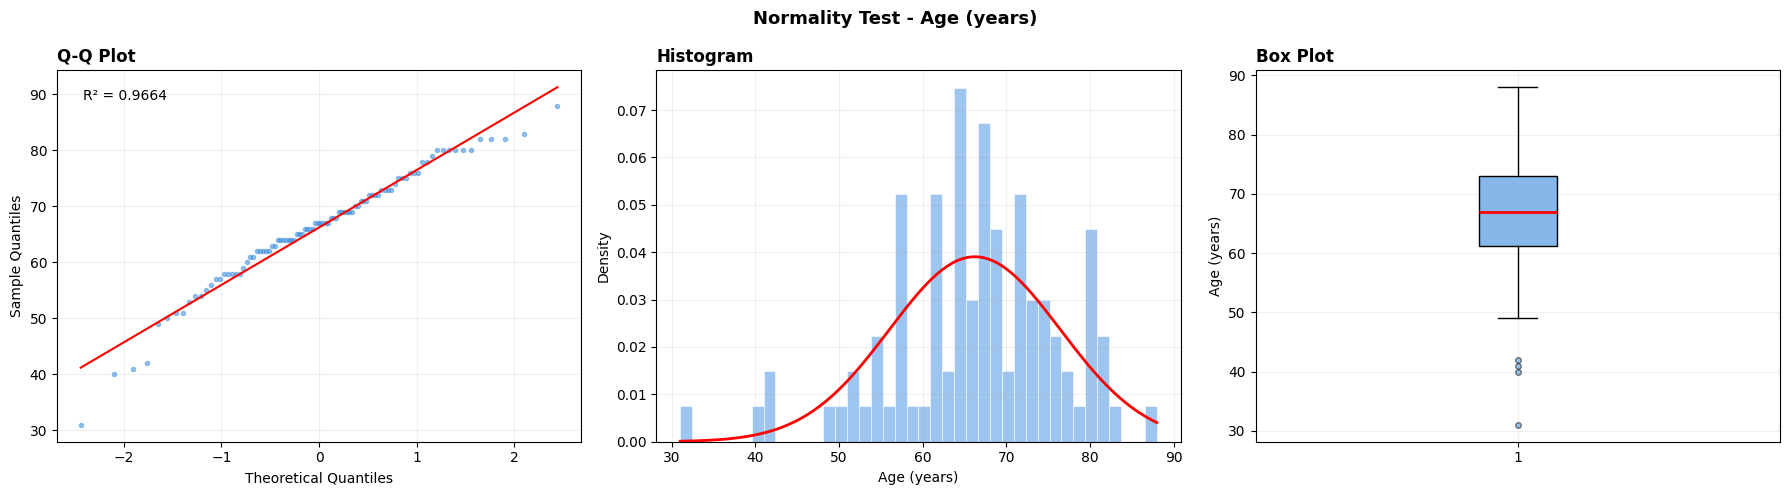


── Shapiro-Wilk test: Length (cm) ──
  Statistic: 0.9848
  P-value:   0.3481
  Conclusion: Normally distributed (p > 0.05)


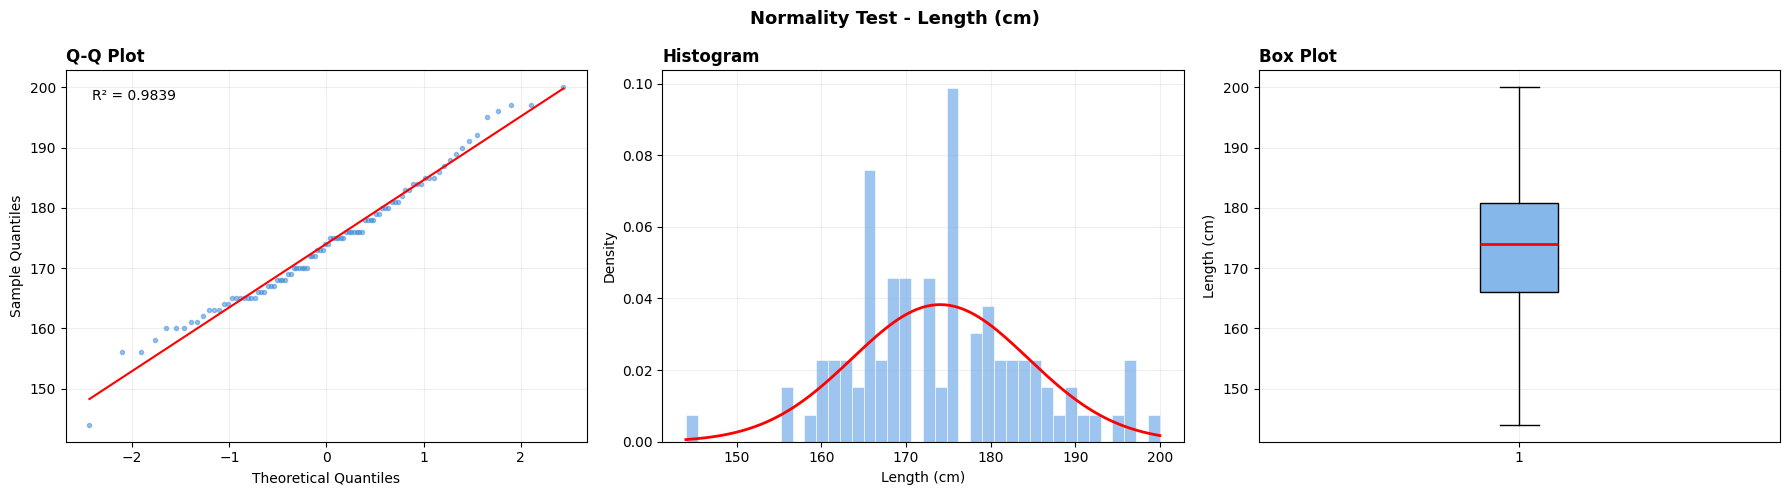


── Shapiro-Wilk test: Weight (kg) ──
  Statistic: 0.9548
  P-value:   0.0026
  Conclusion: Not normally distributed (p < 0.05)


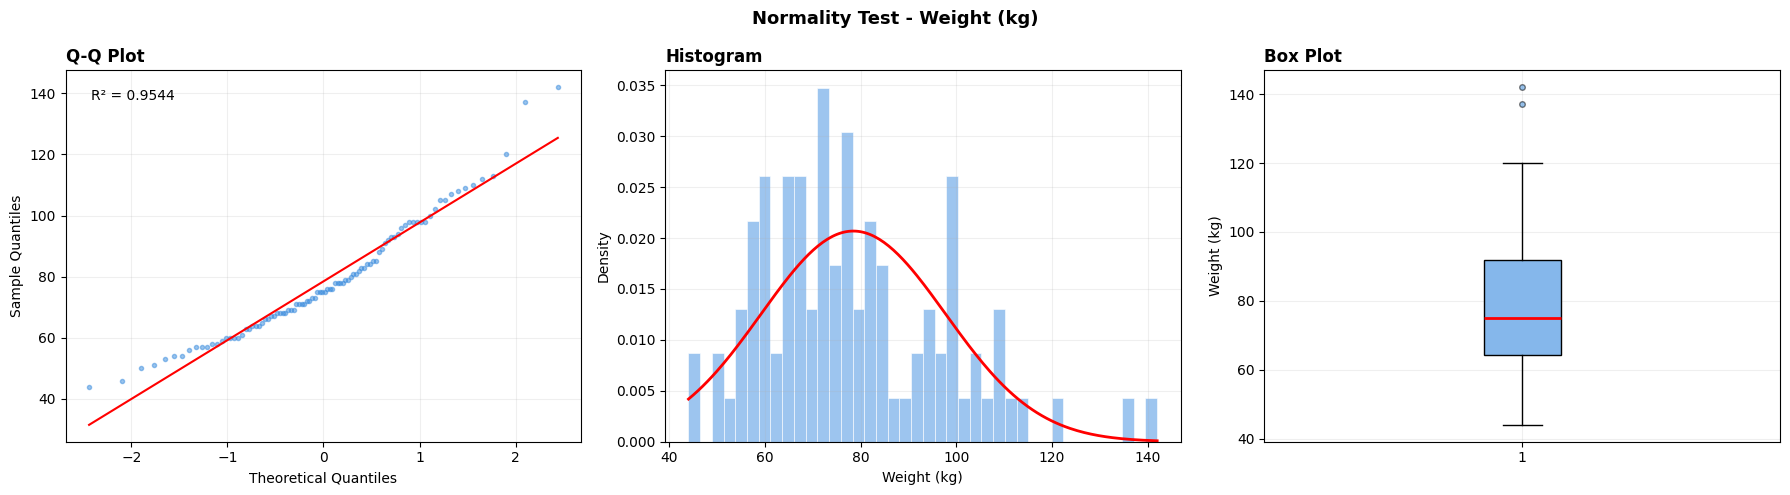

(np.float64(0.9548224592318325), np.float64(0.00258313620303748))

In [16]:
test_normal_distribution(df_final['age_at_surgery'].dropna().values, name='Age (years)')
test_normal_distribution(df_final['dem_height'].dropna().values,     name='Length (cm)')
test_normal_distribution(df_final['dem_weight'].dropna().values,     name='Weight (kg)')

### <center> Descriptive statistics


In [5]:
summary = []

# Age
data = df_final['age_at_surgery'].dropna()
summary.append({
    'Characteristic': 'Age, mean ± SD, years',
    'Validation': f'{data.mean():.1f} ± {data.std():.1f}'
})

# Height
data = df_final['dem_height'].dropna()
summary.append({
    'Characteristic': 'Height, mean ± SD, cm',
    'Validation': f'{data.mean():.1f} ± {data.std():.1f}'
})

# Sex
sex = df_final['dem_sex'].map({'Male': 1, 'Female': 0})
n_total = sex.notna().sum()
n_male = (sex == 1).sum()

summary.append({
    'Characteristic': 'Sex, number male (%)',
    'Validation': f'{n_male} ({100*n_male/n_total:.2f})'
})

# Weight
data = df_final['dem_weight'].dropna()
summary.append({
    'Characteristic': 'Weight, median (IQR), kg',
    'Validation': (
        f'{data.median():.1f} '
        f'({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    )
})

column_name = f'Validation dataset (n={len(df_final)})'

df_summary = pd.DataFrame(summary)
df_summary.columns = ['Characteristic', column_name]

display(df_summary)

,Characteristic,Validation dataset (n=94)
0,"Age, mean ± SD, years",66.2 ± 10.3
1,"Height, mean ± SD, cm",174.0 ± 10.5
2,"Sex, number male (%)",39 (41.49)
3,"Weight, median (IQR), kg",75.0 (64.2-91.8)


### Whitney U test


In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu
import pandas as pd
from scipy.stats import chi2_contingency

pad = r'P:\FINAL_BEFORE_AF15\AF15_MST\npy_files'

idx_test = np.load(pad + r'\indices_test_260610.npy')
idx_train = np.load(pad + r'\indices_train_260610.npy')
idx_val   = np.load(pad + r'\indices_val_260610.npy')
np_c = np.load(pad + r'\np_c_finetune.npy')

print(f'Indices length: {len(idx_test)}')
print(f'Total testsamples: {idx_test.sum()}')

test_patienten = np.unique(np_c[idx_test])
print(f'total testpatients: {len(test_patienten)}')
print(f'Patient IDs: {test_patienten}')

train_patienten = np.unique(np_c[idx_train])
print(f'total trainpatients: {len(train_patienten)}')
print(f'Patient IDs: {train_patienten}')

val_patienten = np.unique(np_c[idx_val])
print(f'total valpatients: {len(val_patienten)}')
print(f'Patient IDs: {val_patienten}')


Indices lengte: 54367
Aantal testsamples: 6158
Aantal testpatiënten: 11
Patiënt IDs: [110015 110019 110028 110044 110049 110075 110094 110104 110108 110114
 110138]
Aantal trainpatiënten: 59
Patiënt IDs: [110006 110007 110009 110011 110016 110018 110021 110025 110026 110027
 110043 110047 110050 110053 110054 110056 110057 110060 110061 110062
 110063 110064 110065 110066 110068 110069 110071 110073 110076 110077
 110078 110079 110082 110084 110085 110086 110087 110088 110089 110090
 110091 110092 110096 110098 110099 110100 110103 110107 110109 110111
 110115 110117 110119 110121 110122 110123 110127 110132 110149]
Aantal valpatiënten: 24
Patiënt IDs: [110002 110008 110020 110024 110030 110046 110052 110058 110059 110072
 110074 110080 110083 110097 110101 110105 110106 110110 110118 110126
 110129 110130 110140 110142]


In [21]:
df_demo = pd.read_csv(
    os.path.join(DATA_PATH, 'df_baseline.csv'),
    sep=';'
)
df_demo['dem_sex'] = (df_demo['dem_sex'].str.strip() == 'Male').astype(int)
df_demo = df_demo.rename(columns={df_demo.columns[0]: 'patient_id'})

df_train = df_demo[df_demo['patient_id'].isin(train_patienten)]
df_val   = df_demo[df_demo['patient_id'].isin(val_patienten)]
df_test  = df_demo[df_demo['patient_id'].isin(test_patienten)]

print(f'Train: {len(df_train)} patients')
print(f'Val:   {len(df_val)} patients')
print(f'Test:  {len(df_test)} patients')

# Mann-Whitney U test
variabelen = ['age_at_surgery', 'dem_height', 'dem_weight']
namen      = ['Age', 'Length', 'Weight']

print('\n── Mann-Whitney U test ──')
print(f'{"Variabel":<12} {"Train-Val p":>12} {"Train-Test p":>13} {"Val-Test p":>11}')
print('-' * 52)

for var, naam in zip(variabelen, namen):
    _, p_tv = mannwhitneyu(df_train[var].dropna(), df_val[var].dropna())
    _, p_tt = mannwhitneyu(df_train[var].dropna(), df_test[var].dropna())
    _, p_vt = mannwhitneyu(df_val[var].dropna(), df_test[var].dropna())
    print(f'{naam:<12} {p_tv:>12.4f} {p_tt:>13.4f} {p_vt:>11.4f}')

# chi-kwadraat
print('\n── Chi-kwadraat test sex ──')
tabel = np.array([
    [df_train['dem_sex'].sum(), len(df_train) - df_train['dem_sex'].sum()],
    [df_val['dem_sex'].sum(),   len(df_val)   - df_val['dem_sex'].sum()],
    [df_test['dem_sex'].sum(),  len(df_test)  - df_test['dem_sex'].sum()]
])
chi2, p, dof, _ = chi2_contingency(tabel)
print(f'Chi-kwadraat: {chi2:.4f}, p = {p:.4f}')

Train: 59 patients
Val:   24 patients
Test:  11 patients

── Mann-Whitney U test ──
Variabel      Train-Val p  Train-Test p  Val-Test p
----------------------------------------------------
Age                0.7174        0.1989      0.5219
Length             0.3816        0.7774      0.5813
Weight             0.9719        0.8275      0.8589

── Chi-kwadraat test sex ──
Chi-kwadraat: 0.9254, p = 0.6296



── Shapiro-Wilk test: Age (years) - Train ──
  Statistic: 0.9867
  P-value:   0.7647
  Conclusion: Normally distributed (p > 0.05)


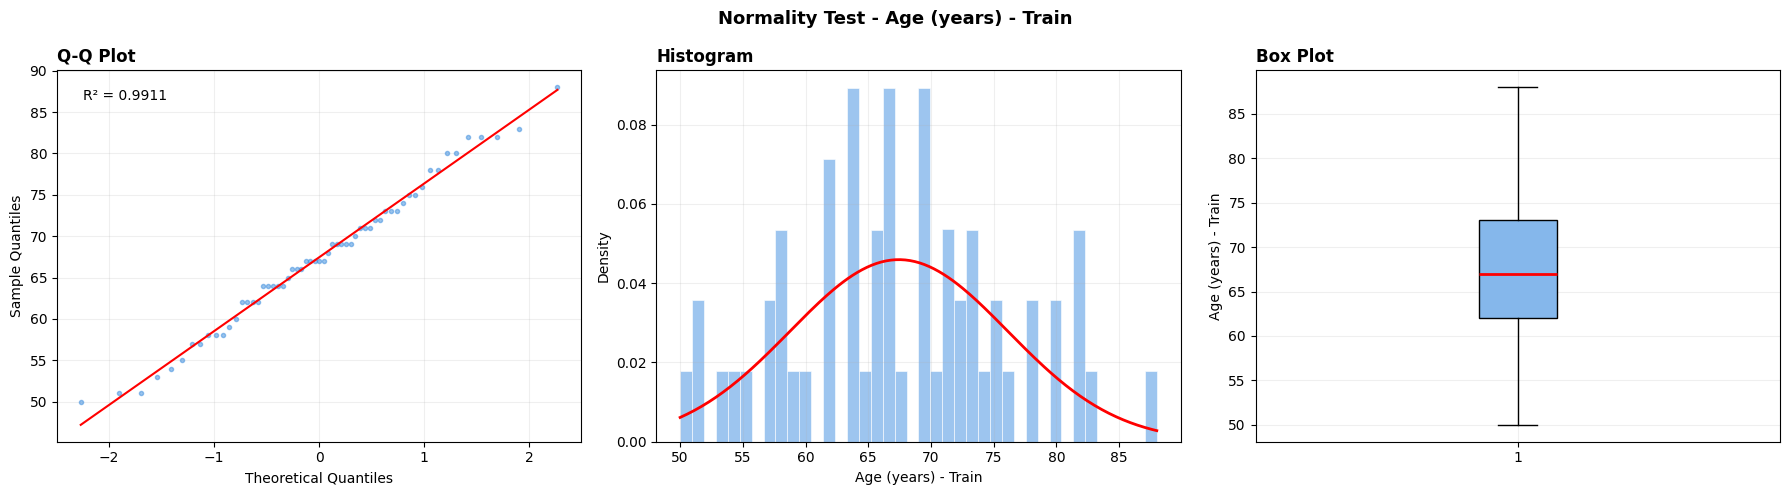


── Shapiro-Wilk test: Height (cm) - Train ──
  Statistic: 0.9854
  P-value:   0.6994
  Conclusion: Normally distributed (p > 0.05)


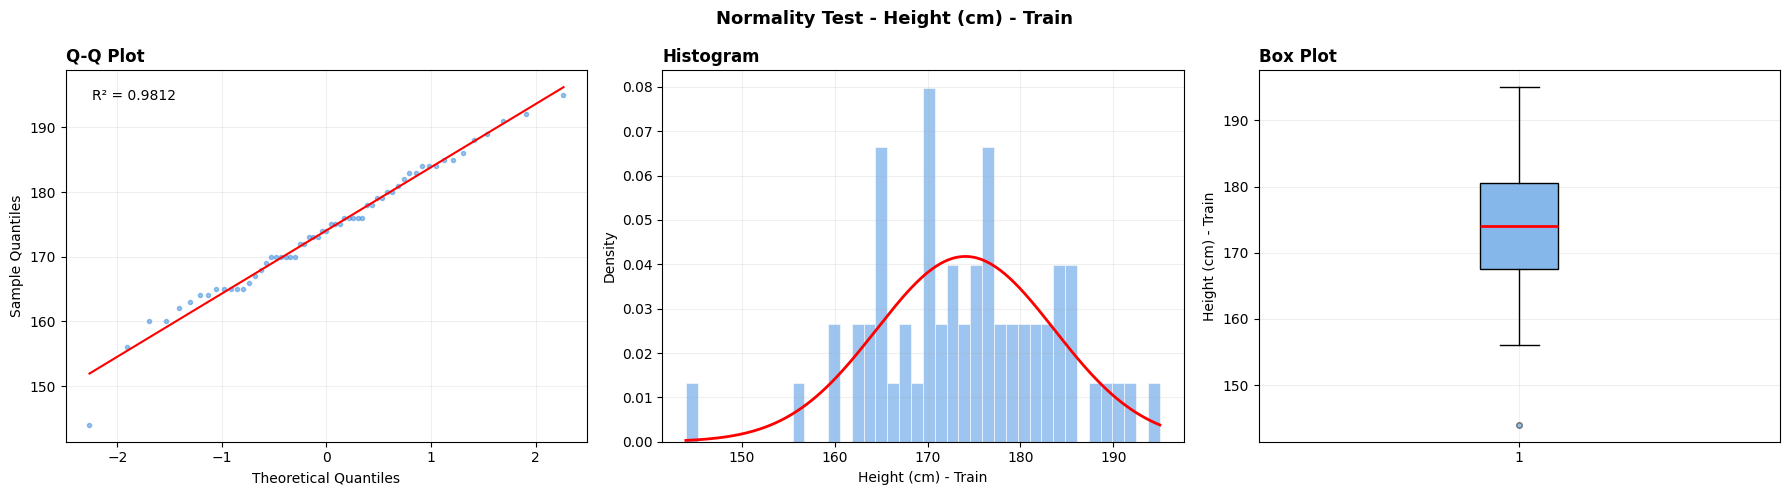


── Shapiro-Wilk test: Weight (kg) - Train ──
  Statistic: 0.9553
  P-value:   0.0297
  Conclusion: Not normally distributed (p < 0.05)


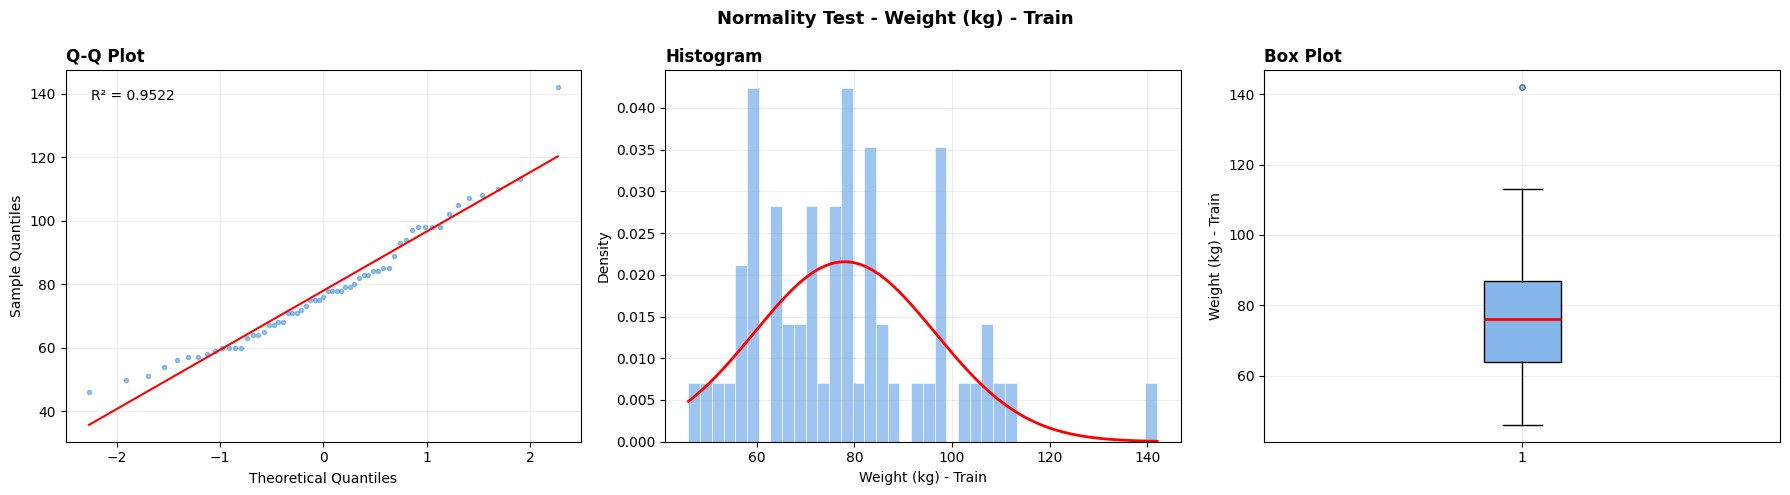


── Shapiro-Wilk test: Age (years) - Validation ──
  Statistic: 0.9012
  P-value:   0.0228
  Conclusion: Not normally distributed (p < 0.05)


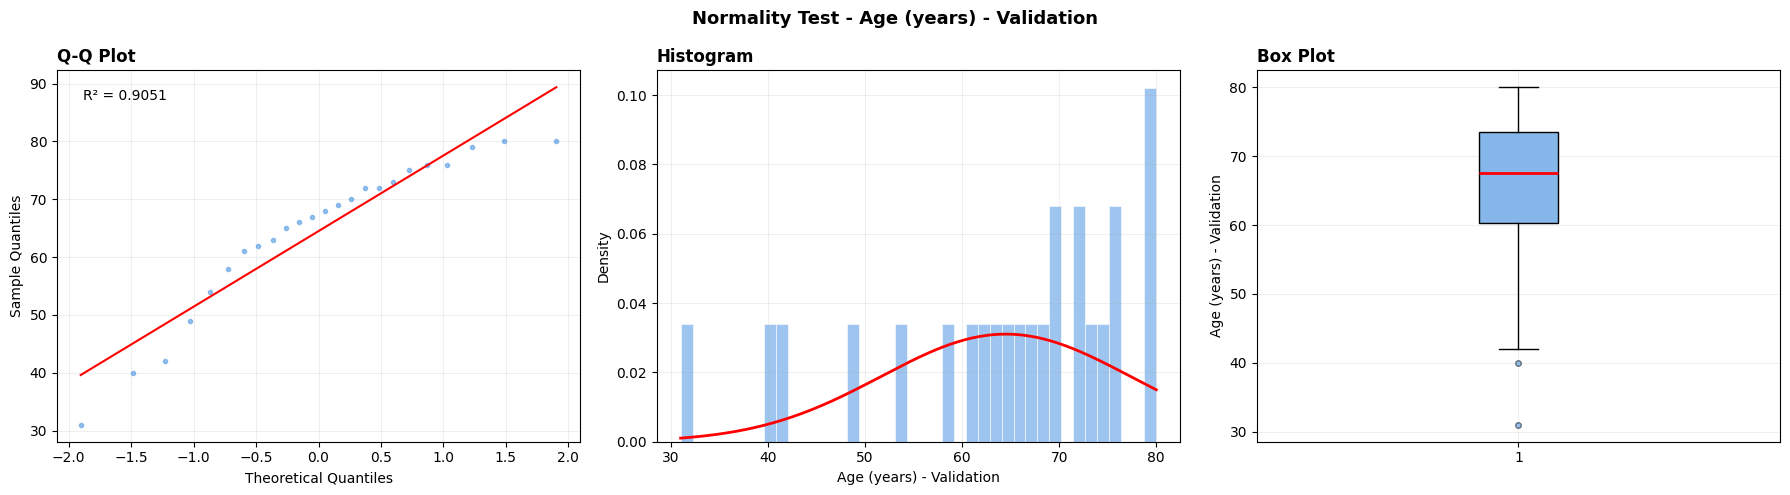


── Shapiro-Wilk test: Height (cm) - Validation ──
  Statistic: 0.8881
  P-value:   0.0122
  Conclusion: Not normally distributed (p < 0.05)


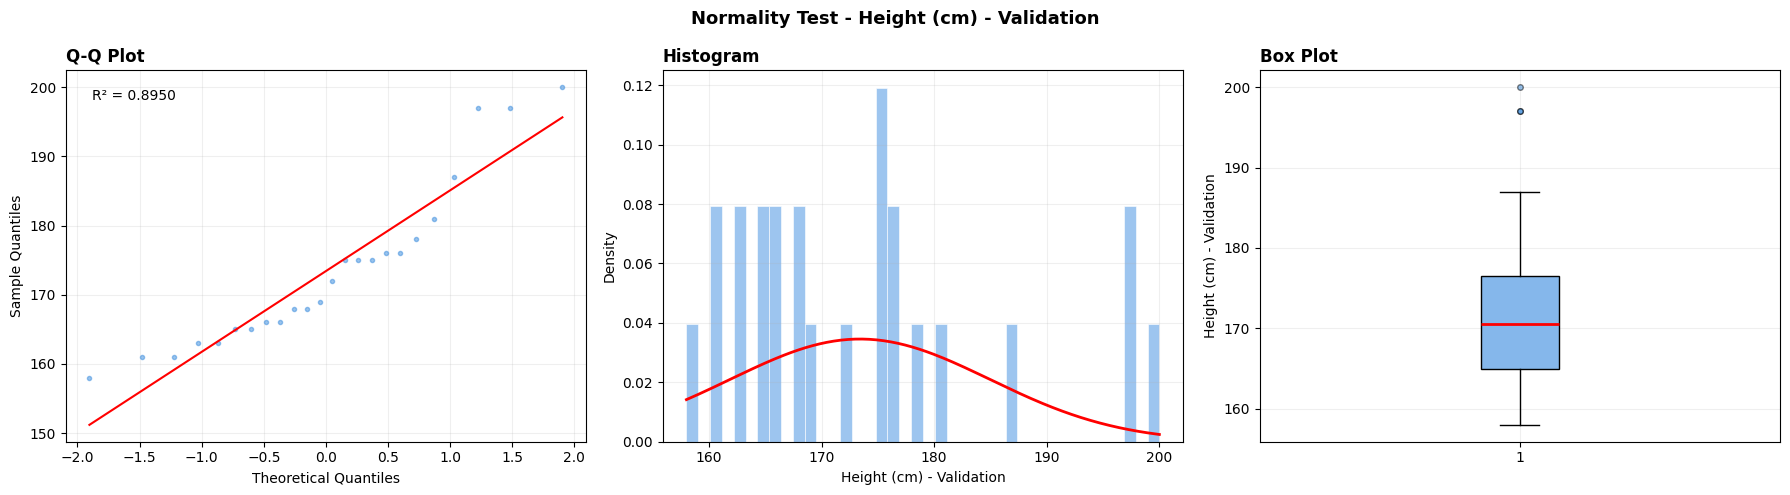


── Shapiro-Wilk test: Weight (kg) - Validation ──
  Statistic: 0.8803
  P-value:   0.0084
  Conclusion: Not normally distributed (p < 0.05)


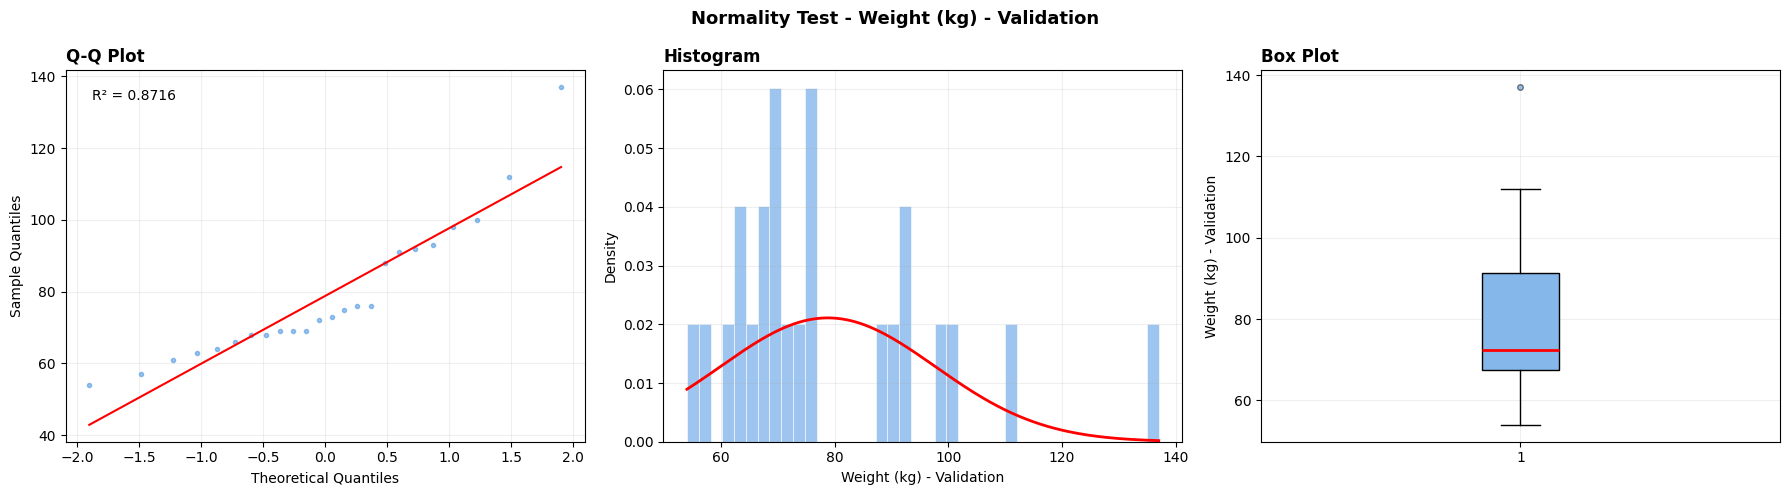


── Shapiro-Wilk test: Age (years) - Test ──
  Statistic: 0.9166
  P-value:   0.2916
  Conclusion: Normally distributed (p > 0.05)


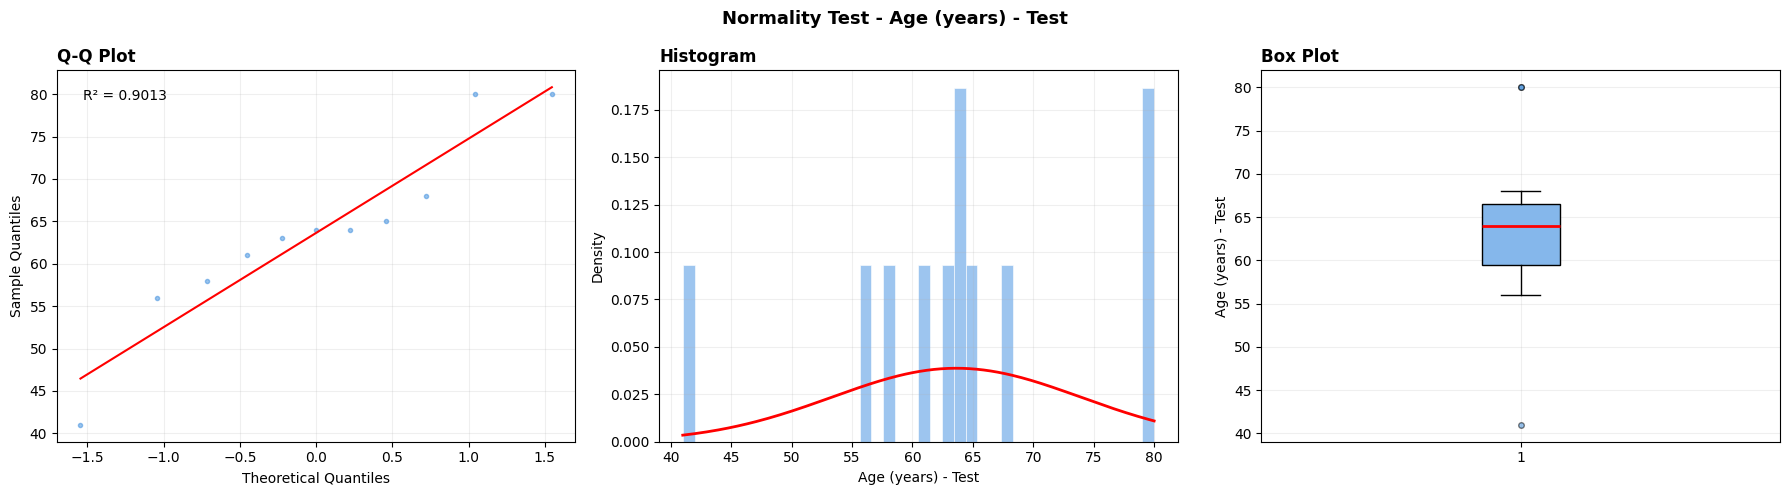


── Shapiro-Wilk test: Height (cm) - Test ──
  Statistic: 0.9643
  P-value:   0.8240
  Conclusion: Normally distributed (p > 0.05)


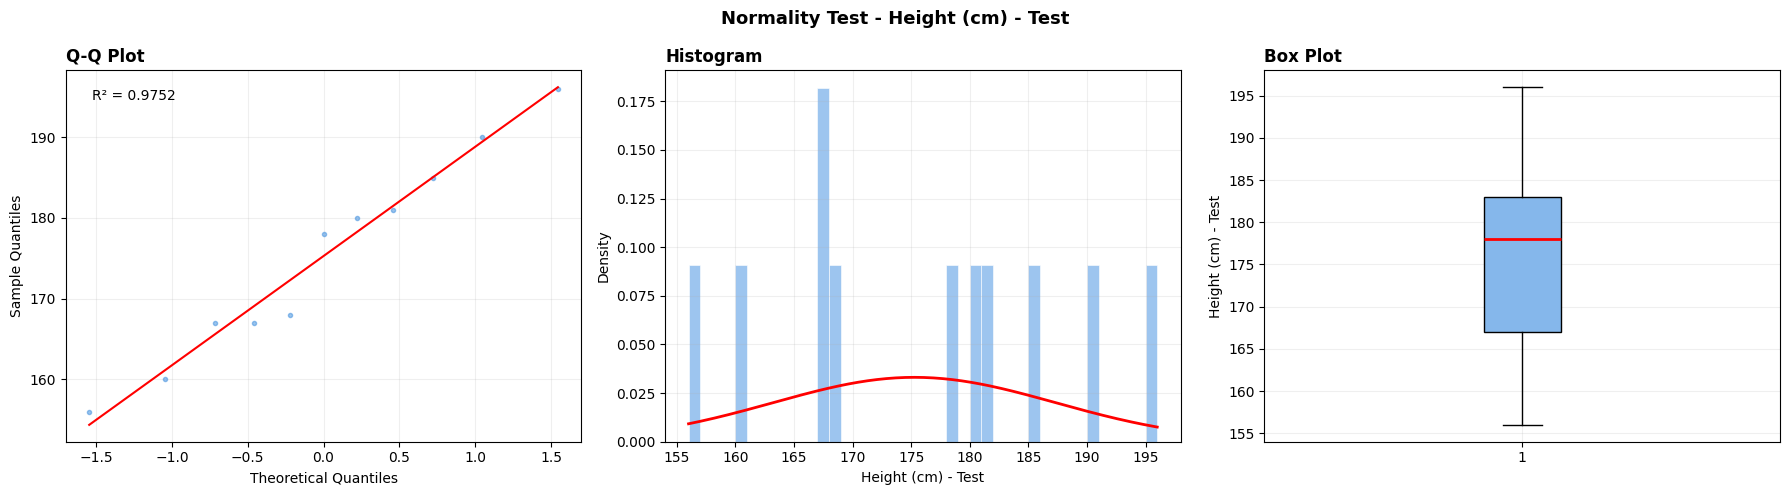


── Shapiro-Wilk test: Weight (kg) - Test ──
  Statistic: 0.9642
  P-value:   0.8225
  Conclusion: Normally distributed (p > 0.05)


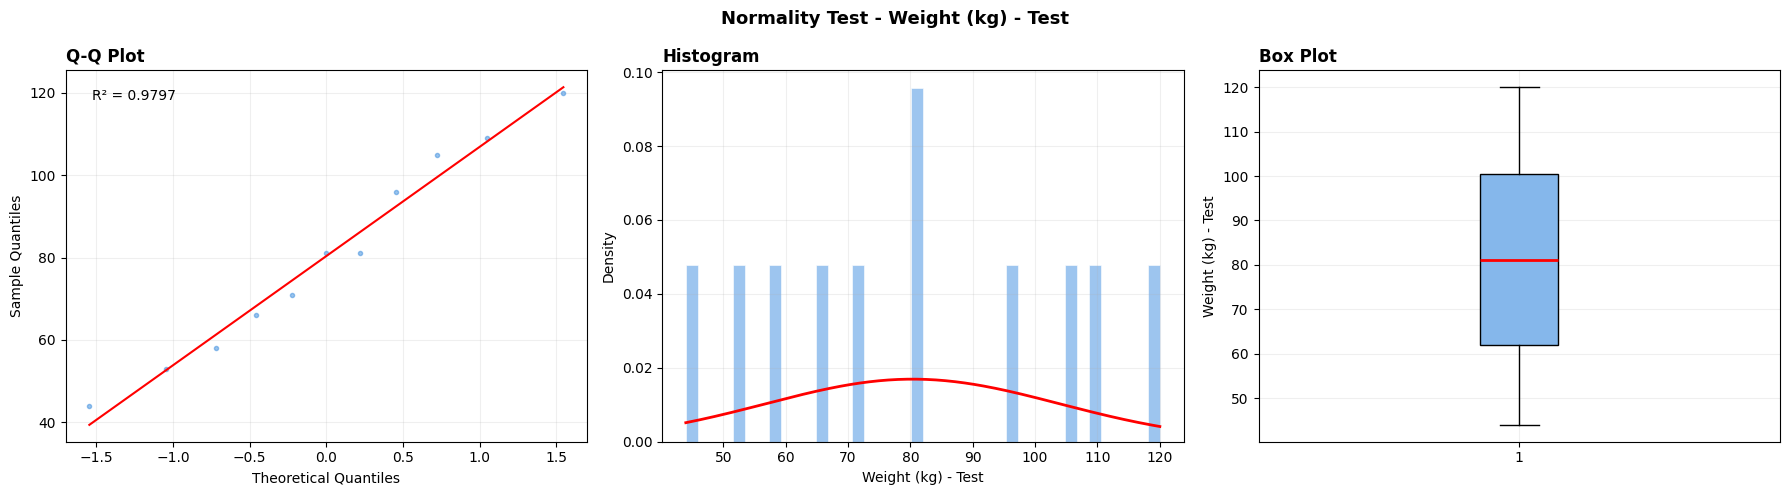

(np.float64(0.9641827689746324), np.float64(0.8225405795178695))

In [20]:
# Train
test_normal_distribution(df_train['age_at_surgery'].values,  name='Age (years) - Train')
test_normal_distribution(df_train['dem_height'].values,      name='Height (cm) - Train')
test_normal_distribution(df_train['dem_weight'].values,      name='Weight (kg) - Train')

# Validation
test_normal_distribution(df_val['age_at_surgery'].values,    name='Age (years) - Validation')
test_normal_distribution(df_val['dem_height'].values,        name='Height (cm) - Validation')
test_normal_distribution(df_val['dem_weight'].values,        name='Weight (kg) - Validation')

# Test
test_normal_distribution(df_test['age_at_surgery'].values,   name='Age (years) - Test')
test_normal_distribution(df_test['dem_height'].values,       name='Height (cm) - Test')
test_normal_distribution(df_test['dem_weight'].values,       name='Weight (kg) - Test')

In [29]:
import pandas as pd

def make_summary(df, Dataset_name):
    summary = []

    # Age
    data = df['age_at_surgery'].dropna()
    summary.append({
        'Characteristic': 'Age, median (IQR), years',
        Dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.2f}-{data.quantile(0.75):.2f})'
    })

    # Height
    data = df['dem_height'].dropna()
    summary.append({
        'Characteristic': 'Height, median (IQR), cm',
        Dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    })

    # Sex
    n_total = df['dem_sex'].notna().sum()
    n_male = (df['dem_sex'] == 1).sum()
    summary.append({
        'Characteristic': 'Sex, number male (%)',
        Dataset_name: f'{n_male} ({100*n_male/n_total:.2f})'
    })

    # Weight
    data = df['dem_weight'].dropna()
    summary.append({
        'Characteristic': 'Weight, median (IQR), kg',
        Dataset_name: f'{data.median():.1f} ({data.quantile(0.25):.1f}-{data.quantile(0.75):.1f})'
    })

    return pd.DataFrame(summary)

# Maak summary per groep
df_sum_train = make_summary(df_train, f'Train (n={len(df_train)})')
df_sum_val   = make_summary(df_val,   f'Validation (n={len(df_val)})')
df_sum_test  = make_summary(df_test,  f'Test (n={len(df_test)})')

# Combineer alle groepen
df_summary = df_sum_train.merge(df_sum_val, on='Characteristic').merge(df_sum_test, on='Characteristic')

display(df_summary)

,Characteristic,Train (n=59),Validation (n=24),Test (n=11)
0,"Age, median (IQR), years",67.0 (62.00-73.00),67.5 (60.25-73.50),64.0 (59.50-66.50)
1,"Height, median (IQR), cm",174.0 (167.5-180.5),170.5 (165.0-176.5),178.0 (167.0-183.0)
2,"Sex, number male (%)",23 (38.98),10 (41.67),6 (54.55)
3,"Weight, median (IQR), kg",76.0 (64.0-87.0),72.5 (67.5-91.2),81.0 (62.0-100.5)
